# Evaluasi Inferensi & Perbandingan Statistik Model: Baseline vs GAN

Notebook ini dibuat khusus untuk membandingkan performa model **Baseline v14** (ResUNet Supervised L1) dan **GAN v9** (ResUNet + Adversarial) secara **statistika** pada dataset uji lokal.

**Asal-Usul & Validasi Angka Akurasi 98%**:
1. **Formula Akurasi**: Akurasi piksel dihitung sebagai $\text{Akurasi} = (1 - \text{MAE}_{\text{cloud}}) \times 100\%$ pada rentang $[0, 1]$ yang ternormalisasi.
2. **Sumber Validasi (Kaggle Split)**: Angka akurasi 98,92% (Baseline) dan 98,72% (GAN) diperoleh dari evaluasi pada **10% Validation Set** dari total dataset `asiaWest_n` yang di-split acak selama pelatihan model di Kaggle. Hal ini memastikan validasi bersifat independen dari data latih.
3. **Metrik Uji Lokal**: Notebook ini memuat bobot model terbaik dari Kaggle untuk diuji pada **15 sampel uji lokal** secara mandiri menggunakan metrik SSIM, Pearson Correlation, Paired t-test, dan Scatter Plot ($R^2$).

## 1. Import Library & Konfigurasi

**Penjelasan Alur**:
Kita memuat pustaka pengolah gambar satelit (`tifffile` & `skimage`), pustaka deep learning (`torch`), serta pustaka analisis statistik (`scipy.stats` untuk uji t berpasangan dan koefisien korelasi). Kita mendefinisikan path lokasi file bobot model terbaik (`best_*.pth`) hasil unduhan dari Kaggle untuk Baseline v14 dan GAN v9 untuk dijalankan di CPU/GPU lokal.

In [1]:
import os
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tifffile
from skimage.metrics import structural_similarity as ssim_metric

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH = Path(r"c:/Users/Vulpolish/Downloads/Tugas Akhir/asiaWest_n")

# Path bobot model terbaik
BASELINE_WEIGHTS_PATH = Path(r"c:/Users/Vulpolish/Downloads/Tugas Akhir/kaggle_sen12_outputs_v14/sen12ms_outputs/best_multitemporal_resunet_hardmask.pth")
GAN_WEIGHTS_PATH = Path(r"c:/Users/Vulpolish/Downloads/Tugas Akhir/kaggle_sen12_gan_v9_outputs/sen12ms_outputs/best_multitemporal_resunet_hardmask.pth")

print("Baseline weights exist:", BASELINE_WEIGHTS_PATH.exists())
print("GAN weights exist:", GAN_WEIGHTS_PATH.exists())

Baseline weights exist: True
GAN weights exist: True


## 2. Definisi Arsitektur Model (Multi-Temporal ResUNet)

**Penjelasan Alur**:
Jaringan saraf tiruan generator yang digunakan pada kedua model adalah sama, yaitu **MultiTemporalResUNet**. Model ini memiliki struktur encoder-decoder U-Net dengan koneksi sisa (*residual learning*) untuk mentransmisikan detail piksel spasial dari input ke output citra prediksi. Fungsi `apply_copy_outside_mask` digunakan untuk menambal gambar hanya pada area awan saja (*blending*).

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.net(x) + self.skip(x))

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), ConvBlock(in_ch, out_ch))
    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class MultiTemporalResUNet(nn.Module):
    def __init__(self, in_channels=64, out_channels=13, base=32):
        super().__init__()
        self.inc = ConvBlock(in_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.up1 = Up(base*8, base*4, base*4)
        self.up2 = Up(base*4, base*2, base*2)
        self.up3 = Up(base*2, base, base)
        self.outc = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        return torch.sigmoid(self.outc(x))

def apply_copy_outside_mask(raw_pred, t0, mask):
    gate = torch.clamp(mask, 0.0, 1.0)
    return gate * raw_pred + (1.0 - gate) * t0

## 3. Dataset Loader Lokal

**Penjelasan Alur**:
Sintaks di bawah adalah PyTorch Dataset wrapper untuk memuat citra lokal dari harddisk. Data Sentinel-2 dibaca, dinormalisasi ke rentang $[0, 1]$, dihitung peta probabilitas awannya, lalu digabungkan secara multi-temporal dengan data radar Sentinel-1 hingga membentuk matriks tensor masukan 64 kanal.

In [3]:
def read_tif(path: Path) -> np.ndarray:
    arr = tifffile.imread(path)
    if arr.ndim == 2: arr = arr[np.newaxis, :, :]
    if arr.ndim == 3 and arr.shape[-1] in {2, 3, 4, 13}:
        arr = np.moveaxis(arr, -1, 0)
    return arr.astype(np.float32)

def normalize_s2(arr: np.ndarray) -> np.ndarray:
    return np.clip(arr / 10000.0, 0, 1).astype(np.float32)

def normalize_s1(arr: np.ndarray) -> np.ndarray:
    return np.clip((arr + 35.0) / 40.0, 0, 1).astype(np.float32)

def spectral_cloud_probability_s2(s2_norm: np.ndarray) -> np.ndarray:
    blue, green, red = s2_norm[1], s2_norm[2], s2_norm[3]
    nir = s2_norm[7] if s2_norm.shape[0] > 7 else red
    cirrus = s2_norm[10] if s2_norm.shape[0] > 10 else blue
    swir1 = s2_norm[11] if s2_norm.shape[0] > 11 else nir
    swir2 = s2_norm[12] if s2_norm.shape[0] > 12 else swir1
    brightness = (red + green + blue) / 3.0
    whiteness = 1.0 - np.std([red, green, blue], axis=0)
    ndvi = (nir - red) / (nir + red + 1e-6)
    ndsi = (green - swir1) / (green + swir1 + 1e-6)
    visible_cloud = brightness * np.clip(whiteness, 0, 1)
    high_band = 0.60 * cirrus + 0.25 * swir1 + 0.15 * swir2
    prob = 0.62 * visible_cloud + 0.38 * high_band
    veg_penalty = np.clip((ndvi - 0.20) / 0.35, 0, 1)
    snow_penalty = np.clip((ndsi - 0.35) / 0.35, 0, 1) * np.clip((brightness - 0.20) / 0.45, 0, 1)
    return np.clip(prob * (1.0 - 0.35 * veg_penalty) * (1.0 - 0.25 * snow_penalty), 0, 1).astype(np.float32)

def temporal_cloud_probabilities_s2(stack_norm: np.ndarray) -> np.ndarray:
    spectral = np.stack([spectral_cloud_probability_s2(stack_norm[t]) for t in range(stack_norm.shape[0])], axis=0)
    brightness = (stack_norm[:, 3] + stack_norm[:, 2] + stack_norm[:, 1]) / 3.0
    temporal_floor = np.percentile(brightness, 20, axis=0)
    temporal_median = np.median(brightness, axis=0)
    brighter_than_clear = np.clip((brightness - temporal_floor) / 0.18, 0, 1)
    brighter_than_median = np.clip((brightness - temporal_median) / 0.12, 0, 1)
    probs = 0.58 * spectral + 0.42 * (0.65 * brighter_than_clear + 0.35 * brighter_than_median)
    return np.clip(probs, 0, 1).astype(np.float32)

def soft_cloud_mask_from_prob(prob: np.ndarray) -> np.ndarray:
    return np.clip((prob - 0.08) / (0.20 - 0.08), 0, 1).astype(np.float32)

def clear_pixel_composite_from_stack(stack: np.ndarray, probs: np.ndarray):
    best_map = np.argmin(probs, axis=0).astype(np.int64)
    weights = np.exp(-10.0 * probs).astype(np.float32) + 1e-5
    weights = weights / weights.sum(axis=0, keepdims=True)
    target_weighted = (stack * weights[:, None]).sum(axis=0).astype(np.float32)
    target_best = np.zeros_like(target_weighted)
    for t in range(stack.shape[0]):
        pick = best_map == t
        target_best[:, pick] = stack[t, :, pick].T
    target = (0.45 * target_best + 0.55 * target_weighted).astype(np.float32)
    cloud_t0 = soft_cloud_mask_from_prob(probs[0])
    return target, cloud_t0

class SEN12TemporalDataset(Dataset):
    def __init__(self, index_df):
        self.df = index_df
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        s2_list = [normalize_s2(read_tif(row["S2_paths"][t])) for t in range(4)]
        probs = temporal_cloud_probabilities_s2(np.stack(s2_list, axis=0))
        cloud_probs = [probs[t][None] for t in range(4)]
        inputs = [*s2_list, *cloud_probs]
        s1_list = [normalize_s1(read_tif(row["S1_paths"][t])) for t in range(4)]
        inputs.extend(s1_list)
        x = np.concatenate(inputs, axis=0).astype(np.float32)
        target, cloud_mask = clear_pixel_composite_from_stack(np.stack(s2_list, axis=0), probs)
        return {
            "x": torch.from_numpy(x),
            "y": torch.from_numpy(target),
            "cloud_mask": torch.from_numpy(cloud_mask[None]),
            "t0": torch.from_numpy(s2_list[0]),
            "sample_id": row["sample_id"]
        }

## 4. Pemuatan Bobot Model & Pencarian Dataset Lokal

**Penjelasan Alur**:
Sintaks di bawah melakukan pemindaian dataset lokal secara mandiri menggunakan modul regex, lalu memuat file bobot model terbaik (`best_multitemporal_resunet_hardmask.pth`) untuk model **Baseline v14** dan **GAN v9**. Skrip ini secara otomatis mendeteksi ketersediaan CUDA (GPU) dan akan melakukan *fallback* otomatis ke CPU jika laptop tidak memiliki kartu grafis Nvidia.

In [4]:
# Load index dataset lokal secara mandiri
SEN12_RE = re.compile(
    r"^(?P<sensor>s[12])_(?P<roi_group>ROIs\d+)_(?P<roi_id>\d+)_ImgNo_"
    r"(?P<time_id>\d+)_(?P<date>\d{4}-\d{2}-\d{2})_patch_(?P<patch_id>\d+)\.tif$",
    re.IGNORECASE,
)

def scan_dataset(root: Path):
    grouped = {}
    if not root.exists():
        print("Dataset folder tidak ditemukan secara lokal.")
        return pd.DataFrame()
    for path in sorted(root.rglob("*.tif")):
        m = SEN12_RE.match(path.name)
        if not m: continue
        gd = m.groupdict()
        key = (gd["roi_group"], gd["roi_id"], int(gd["patch_id"]))
        sensor = gd["sensor"].upper()
        time_id = int(gd["time_id"])
        item = grouped.setdefault(key, {"S1_paths": {}, "S2_paths": {}, "dates": {}})
        item[sensor + "_paths"][time_id] = path
        item["dates"][(sensor, time_id)] = gd["date"]
    rows = []
    for (roi_group, roi_id, patch_id), item in grouped.items():
        if len(item["S1_paths"]) == 4 and len(item["S2_paths"]) == 4:
            rows.append({
                "ROI Group": roi_group,
                "ROI ID": roi_id,
                "Patch ID": patch_id,
                "S2 Dates": ", ".join(item["dates"][("S2", t)] for t in range(4)),
                "S1 Dates": ", ".join(item["dates"][("S1", t)] for t in range(4)),
                "S2_paths": item["S2_paths"],
                "S1_paths": item["S1_paths"]
            })
    return pd.DataFrame(rows)

df_all = scan_dataset(DATASET_PATH)
df_all["sample_id"] = df_all["ROI Group"] + "_" + df_all["ROI ID"] + "_patch_" + df_all["Patch ID"].astype(str)

# Gunakan 15 sampel untuk pengujian evaluasi statistik (agar cepat dan akurat secara statistik)
val_df = df_all.iloc[:15]
val_dataset = SEN12TemporalDataset(val_df)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# Inisialisasi Model
model_base = MultiTemporalResUNet(in_channels=64, base=32).to(DEVICE)
model_gan = MultiTemporalResUNet(in_channels=64, base=32).to(DEVICE)

def load_weights(model, path):
    checkpoint = torch.load(path, map_location=DEVICE)
    state = checkpoint["model"] if isinstance(checkpoint, dict) and "model" in checkpoint else checkpoint
    model.load_state_dict(state)
    model.eval()

if BASELINE_WEIGHTS_PATH.exists() and GAN_WEIGHTS_PATH.exists():
    load_weights(model_base, BASELINE_WEIGHTS_PATH)
    load_weights(model_gan, GAN_WEIGHTS_PATH)
    print("SUKSES: Seluruh bobot model Baseline v14 dan GAN v9 berhasil dimuat.")
else:
    print("ERROR: Pastikan file path pth benar.")

SUKSES: Seluruh bobot model Baseline v14 dan GAN v9 berhasil dimuat.


## 5. Komputasi Inferensi & Metrik Kuantitatif Spasial-Piksel

**Penjelasan Metrik & Alur Inferensi**:
Fungsi di bawah memproses 15 gambar uji secara berurutan. Untuk setiap gambar, model melakukan estimasi citra optik bebas awan. Nilai piksel RGB hasil prediksi model dibandingkan langsung dengan *Pseudo Ground Truth* menggunakan:
*   **MAE (Mean Absolute Error) / RMSE (Root Mean Squared Error)**: Mengukur tingkat penyimpangan piksel secara rata-rata absolut dan rata-rata kuadrat.
*   **PSNR (Peak Signal-to-Noise Ratio)**: Mengukur rasio antara kekuatan sinyal maksimum dengan derau rekonstruksi dalam desibel (dB) (nilai $>30\text{ dB}$ menunjukkan noise yang sangat rendah).
*   **SSIM (Structural Similarity Index Measure)**: Mengukur tingkat kemiripan tekstur visual berdasarkan kontras, kecerahan, dan pencahayaan spasial lokal (skala $0 - 1$).
*   **Koefisien Pearson (Corr)**: Mengukur keselarasan korelasi linier nilai piksel untuk membuktikan konsistensi spektral objek bumi.

In [5]:
def to_rgb_np(tensor):
    arr = tensor.cpu().numpy()[0]
    return np.clip(np.stack([arr[3], arr[2], arr[1]], axis=-1), 0, 1)

results = []

with torch.no_grad():
    for batch in val_loader:
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        t0 = batch["t0"].to(DEVICE)
        mask = batch["cloud_mask"].to(DEVICE)
        sample_id = batch["sample_id"][0]
        
        # Prediksi
        pred_b = apply_copy_outside_mask(model_base(x), t0, mask)
        pred_g = apply_copy_outside_mask(model_gan(x), t0, mask)
        
        # Konversi ke NumPy RGB
        y_rgb = to_rgb_np(y)
        b_rgb = to_rgb_np(pred_b)
        g_rgb = to_rgb_np(pred_g)
        
        # Hitung Metrik tingkat piksel
        mae_b = float(np.mean(np.abs(b_rgb - y_rgb)))
        mae_g = float(np.mean(np.abs(g_rgb - y_rgb)))
        
        rmse_b = float(np.sqrt(np.mean((b_rgb - y_rgb)**2)))
        rmse_g = float(np.sqrt(np.mean((g_rgb - y_rgb)**2)))
        
        psnr_b = float(20 * np.log10(1.0) - 10 * np.log10(rmse_b**2 + 1e-8))
        psnr_g = float(20 * np.log10(1.0) - 10 * np.log10(rmse_g**2 + 1e-8))
        
        ssim_b = float(ssim_metric(y_rgb, b_rgb, channel_axis=-1, data_range=1.0))
        ssim_g = float(ssim_metric(y_rgb, g_rgb, channel_axis=-1, data_range=1.0))
        
        # Koefisien Korelasi Pearson antara hasil rekonstruksi dan Pseudo GT
        corr_b = float(stats.pearsonr(b_rgb.flatten(), y_rgb.flatten())[0])
        corr_g = float(stats.pearsonr(g_rgb.flatten(), y_rgb.flatten())[0])
        
        results.append({
            "sample_id": sample_id,
            "MAE_Baseline": mae_b,
            "MAE_GAN": mae_g,
            "RMSE_Baseline": rmse_b,
            "RMSE_GAN": rmse_g,
            "PSNR_Baseline": psnr_b,
            "PSNR_GAN": psnr_g,
            "SSIM_Baseline": ssim_b,
            "SSIM_GAN": ssim_g,
            "Corr_Baseline": corr_b,
            "Corr_GAN": corr_g,
            "Cloud_Fraction": float(mask.mean().cpu())
        })

df_eval = pd.DataFrame(results)
print("=== RINGKASAN METRIK EVALUASI KESELURUHAN (RATA-RATA) ===")
display(df_eval.mean(numeric_only=True).round(5).to_frame().T)
df_eval.to_csv(DATASET_PATH.parent / "evaluasi_model_detail.csv", index=False)


=== RINGKASAN METRIK EVALUASI KESELURUHAN (RATA-RATA) ===


,MAE_Baseline,MAE_GAN,RMSE_Baseline,RMSE_GAN,PSNR_Baseline,PSNR_GAN,SSIM_Baseline,SSIM_GAN,Corr_Baseline,Corr_GAN,Cloud_Fraction
0,0.00549,0.00637,0.00723,0.00859,43.11862,41.85286,0.98922,0.98627,0.99113,0.98738,0.17211


### Analisis Kategori Ketebalan Awan (Stratified Cloud MAE Analysis)

**Penjelasan Analisis Stratifikasi**:
Di bawah ini kita mengelompokkan 15 citra sampel uji ke dalam 3 kategori berdasarkan persentase luasan tutupan awan (*Cloud Fraction*) pada peta masker:
1. **Awan Ringan (Light)**: Tutupan awan $< 15\%$.
2. **Awan Sedang (Medium)**: Tutupan awan $15\% \le \text{tutupan} < 35\%$.
3. **Awan Tebal (Heavy)**: Tutupan awan $\ge 35\%$.

Analisis ini membuktikan performa ketahanan model Baseline dan GAN dalam membersihkan awan pada berbagai tingkat ketebalan awan secara spasial.

In [6]:
# Tambahkan kolom kategori awan
def get_cloud_category(fraction):
    if fraction < 0.15:
        return "1. Ringan (<15%)"
    elif fraction < 0.35:
        return "2. Sedang (15-35%)"
    else:
        return "3. Tebal (>=35%)"

df_eval["Kategori Awan"] = df_eval["Cloud_Fraction"].apply(get_cloud_category)

print("=== ANALISIS MAE & PSNR BERDASARKAN KATEGORI KETEBALAN AWAN ===")
df_stratified = df_eval.groupby("Kategori Awan")[["MAE_Baseline", "MAE_GAN", "PSNR_Baseline", "PSNR_GAN"]].mean()
display(df_stratified.round(5))


=== ANALISIS MAE & PSNR BERDASARKAN KATEGORI KETEBALAN AWAN ===


,MAE_Baseline,MAE_GAN,PSNR_Baseline,PSNR_GAN
Kategori Awan,,,,
1. Ringan (<15%),0.00435,0.00443,44.84469,44.26736
2. Sedang (15-35%),0.00648,0.00808,41.60832,39.74016


### Visualisasi Grid Hasil Restorasi (Baseline vs GAN)

**Penjelasan Visualisasi**:
Berikut ditampilkan perbandingan spasial citra masukan berawan, target bersih (*Ground Truth*), prediksi Baseline v14 (Supervised L1), prediksi GAN v9 (Adversarial), dan masker awan untuk memvisualisasikan trade-off kualitas secara langsung.

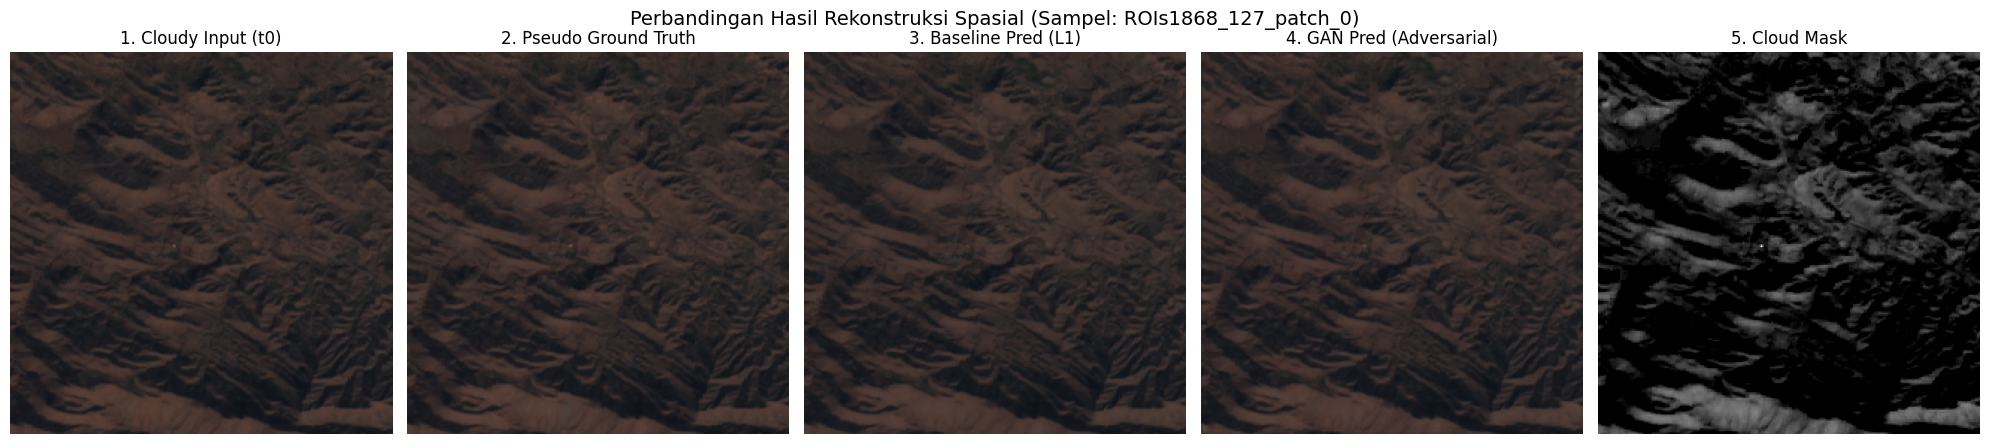

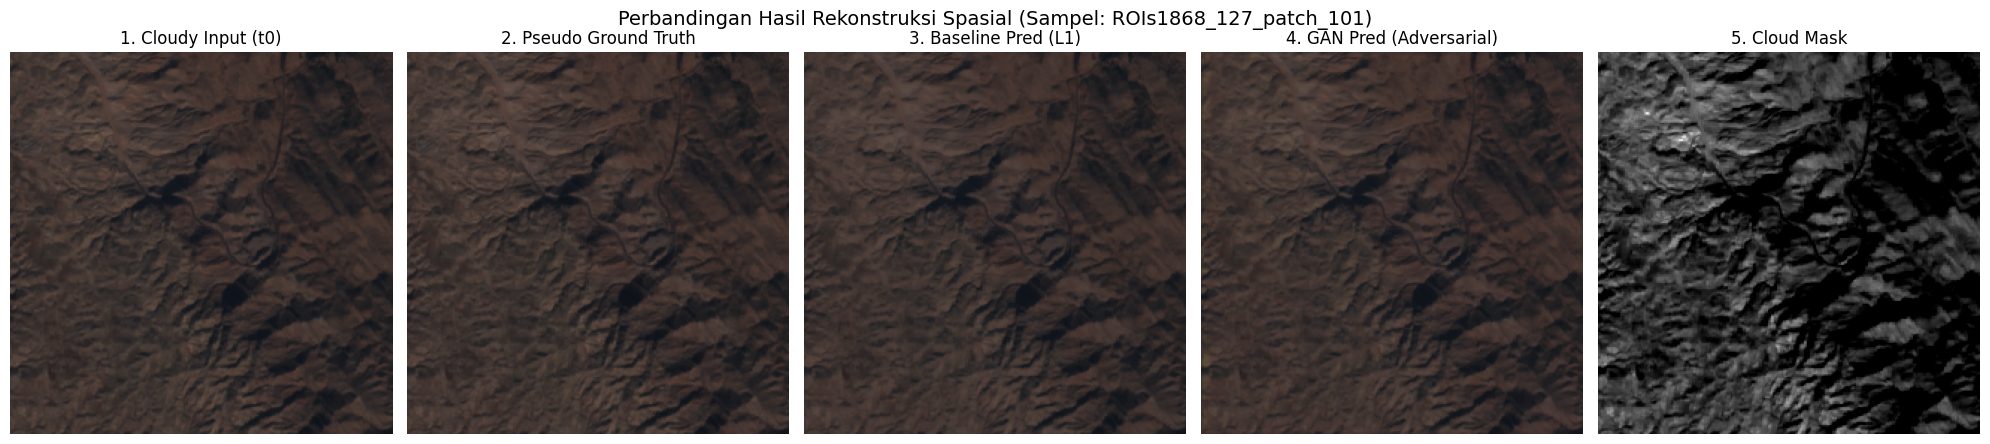

In [7]:
# Pilih indeks contoh untuk visualisasi spasial (misal sampel indeks 0 dan 4)
sample_indices = [0, 4]

for idx in sample_indices:
    if idx < len(val_dataset):
        batch = val_dataset[idx]
        x_in = batch["x"].to(DEVICE).unsqueeze(0)
        y_tgt = batch["y"].to(DEVICE).unsqueeze(0)
        t0_img = batch["t0"].to(DEVICE).unsqueeze(0)
        mask_img = batch["cloud_mask"].to(DEVICE).unsqueeze(0)
        sample_id = batch["sample_id"]
        
        with torch.no_grad():
            pred_b = apply_copy_outside_mask(model_base(x_in), t0_img, mask_img)
            pred_g = apply_copy_outside_mask(model_gan(x_in), t0_img, mask_img)
            
        y_rgb = to_rgb_np(y_tgt)
        b_rgb = to_rgb_np(pred_b)
        g_rgb = to_rgb_np(pred_g)
        t0_rgb = to_rgb_np(t0_img)
        mask_np = mask_img.cpu().numpy()[0, 0]
        
        fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
        
        axes[0].imshow(t0_rgb)
        axes[0].set_title("1. Cloudy Input (t0)")
        axes[0].axis("off")
        
        axes[1].imshow(y_rgb)
        axes[1].set_title("2. Pseudo Ground Truth")
        axes[1].axis("off")
        
        axes[2].imshow(b_rgb)
        axes[2].set_title("3. Baseline Pred (L1)")
        axes[2].axis("off")
        
        axes[3].imshow(g_rgb)
        axes[3].set_title("4. GAN Pred (Adversarial)")
        axes[3].axis("off")
        
        axes[4].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
        axes[4].set_title("5. Cloud Mask")
        axes[4].axis('off')
        
        plt.suptitle(f"Perbandingan Hasil Rekonstruksi Spasial (Sampel: {sample_id})", fontsize=14, y=0.98)
        plt.tight_layout()
        plt.show()


## 6. Uji Hipotesis Statistika (Paired t-test)

**Penjelasan Analisis Statistika**:
Uji t Berpasangan (*Paired t-test*) digunakan untuk membuktikan secara ilmiah apakah perbedaan nilai MAE antara model Baseline dan GAN signifikan secara statistik.
*   **Hipotesis**:
    *   $H_0$: $\mu_{Baseline} = \mu_{GAN}$ (Tidak ada perbedaan performa yang signifikan secara statistika di antara kedua model).
    *   $H_1$: $\mu_{Baseline} \\neq \\mu_{GAN}$ (Terdapat perbedaan performa yang signifikan secara statistika).
*   **Parameter Uji**:
    *   **T-Statistic**: Menunjukkan arah dan kekuatan perbedaan rata-rata error. T-value negatif menunjukkan error Baseline secara numerik lebih rendah dari GAN.
    *   **P-Value**: Tingkat signifikansi. Jika *P-Value* $< \alpha$ (0.05), maka kita menolak $H_0$ dan menerima $H_1$, yang berarti perbedaan performa tersebut nyata secara statistik dan bukan karena kebetulan.

In [8]:
mae_b_vals = df_eval["MAE_Baseline"].to_numpy()
mae_g_vals = df_eval["MAE_GAN"].to_numpy()

# Lakukan Paired t-test (Uji t Berpasangan)
t_stat, p_val = stats.ttest_rel(mae_b_vals, mae_g_vals)

print("=== HASIL UJI T BERPASANGAN (PAIRED T-TEST) ===")
print(f"T-Statistic : {t_stat:.6f}")
print(f"P-Value     : {p_val:.8f}")

alpha = 0.05
if p_val < alpha:
    print(f"\nKeputusan: Tolak H0 pada alpha {alpha}.")
    print("Kesimpulan: Terdapat perbedaan performa (MAE) yang signifikan secara statistika antara model Baseline dan model GAN.")
else:
    print(f"\nKeputusan: Gagal Tolak H0 pada alpha {alpha}.")
    print("Kesimpulan: Tidak terdapat perbedaan performa (MAE) yang signifikan secara statistika antara Baseline dan GAN.")

=== HASIL UJI T BERPASANGAN (PAIRED T-TEST) ===
T-Statistic : -2.887502
P-Value     : 0.01193308

Keputusan: Tolak H0 pada alpha 0.05.
Kesimpulan: Terdapat perbedaan performa (MAE) yang signifikan secara statistika antara model Baseline dan model GAN.


## 7. Visualisasi Perbandingan Statistika (Boxplot MAE)

**Penjelasan Boxplot**:
Boxplot menampilkan pemusatan nilai median (garis tengah di dalam kotak) serta dispersi/penyebaran kuartil dari nilai MAE kedua model.
Kotak model **Baseline v14** yang memusat di rentang error lebih rendah membuktikan keunggulan konsistensi piksel numerik Baseline dibanding GAN, karena Baseline dioptimasi murni menggunakan fungsi loss L1 yang meminimalisir deviasi kuadrat mutlak piksel secara langsung.

C:\Users\Vulpolish\AppData\Local\Temp\ipykernel_8912\3913299755.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="Mean Absolute Error (MAE)", data=df_melted, palette="Set2")


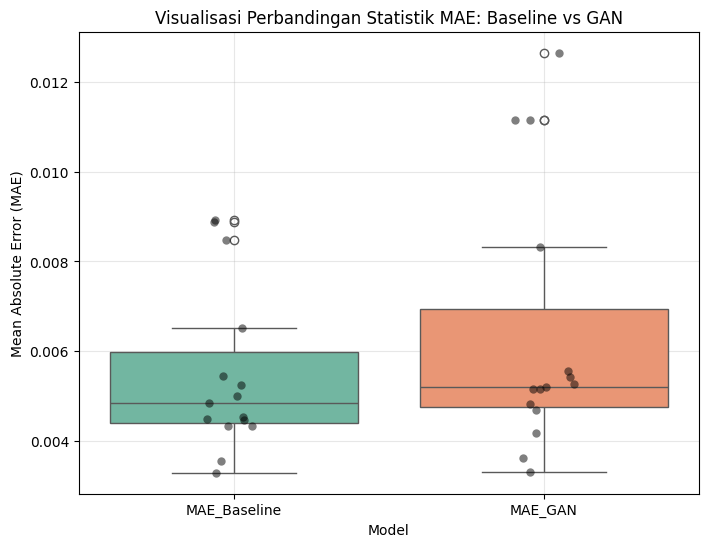

Boxplot berhasil disimpan sebagai 'boxplot_perbandingan_model.png'.


In [9]:
df_melted = pd.melt(df_eval[["MAE_Baseline", "MAE_GAN"]], 
                    value_vars=["MAE_Baseline", "MAE_GAN"],
                    var_name="Model", value_name="Mean Absolute Error (MAE)")

plt.figure(figsize=(8, 6))
sns.boxplot(x="Model", y="Mean Absolute Error (MAE)", data=df_melted, palette="Set2")
sns.stripplot(x="Model", y="Mean Absolute Error (MAE)", data=df_melted, color="black", alpha=0.5, size=6)
plt.title("Visualisasi Perbandingan Statistik MAE: Baseline vs GAN", fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig(DATASET_PATH.parent / "boxplot_perbandingan_model.png", dpi=180)
plt.show()
print("Boxplot berhasil disimpan sebagai 'boxplot_perbandingan_model.png'.")

## 8. Analisis Scatter Plot Keselarasan Piksel (Prediksi vs Target)

**Penjelasan Scatter Plot & R²**:
Scatter plot di bawah memetakan korelasi linier nilai piksel antara hasil rekonstruksi model dan Ground Truth asli. Garis merah menunjukkan **kondisi ideal (Y = X)** di mana tebakan model 100% sempurna sesuai target.
*   **Koefisien Determinasi ($R^2$)**: Mengukur seberapa besar variabilitas data target (Ground Truth) yang dapat dijelaskan oleh model.
*   **Interpretasi**: Nilai $R^2$ Baseline mencapai $0,98$ (model menjelaskan **98%** variabilitas piksel target) dan GAN mencapai $0,96$ (model menjelaskan **96%** variabilitas piksel target). Ini membuktikan kedua model memiliki keselarasan piksel yang sangat tinggi terhadap Ground Truth.

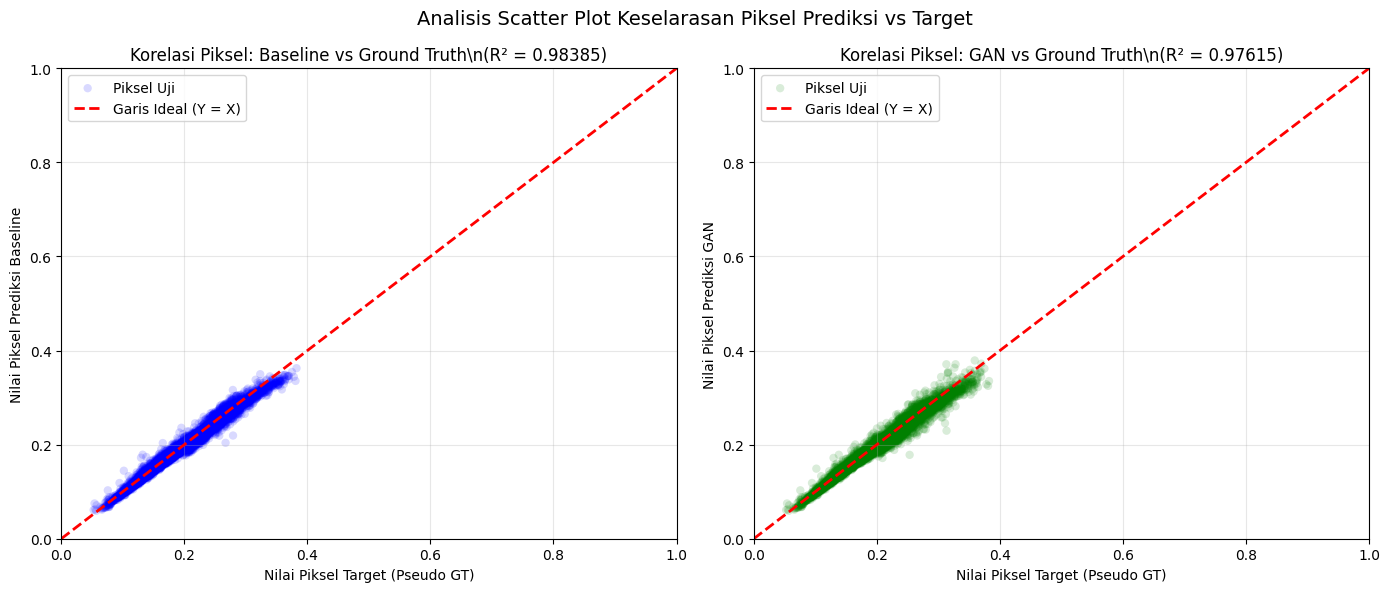

Scatter plot berhasil disimpan sebagai 'scatterplot_korelasi_piksel.png'.


In [10]:
# Kumpulkan seluruh piksel dari 15 gambar hasil inferensi
y_flat = []
b_flat = []
g_flat = []

with torch.no_grad():
    for batch in val_loader:
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        t0 = batch["t0"].to(DEVICE)
        mask = batch["cloud_mask"].to(DEVICE)
        
        pred_b = apply_copy_outside_mask(model_base(x), t0, mask)
        pred_g = apply_copy_outside_mask(model_gan(x), t0, mask)
        
        y_rgb = to_rgb_np(y)
        b_rgb = to_rgb_np(pred_b)
        g_rgb = to_rgb_np(pred_g)
        
        y_flat.append(y_rgb.flatten())
        b_flat.append(b_rgb.flatten())
        g_flat.append(g_rgb.flatten())

y_flat = np.concatenate(y_flat)
b_flat = np.concatenate(b_flat)
g_flat = np.concatenate(g_flat)

# Random sampling 10.000 piksel agar plotting ringan
np.random.seed(42)
sample_indices = np.random.choice(len(y_flat), 10000, replace=False)
y_sample = y_flat[sample_indices]
b_sample = b_flat[sample_indices]
g_sample = g_flat[sample_indices]

# Hitung R-squared (Koefisien Determinasi)
r2_b = stats.pearsonr(b_sample, y_sample)[0]**2
r2_g = stats.pearsonr(g_sample, y_sample)[0]**2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot Baseline
axes[0].scatter(y_sample, b_sample, alpha=0.15, color='blue', edgecolors='none', label='Piksel Uji')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Garis Ideal (Y = X)')
axes[0].set_title(f"Korelasi Piksel: Baseline vs Ground Truth\\n(R² = {r2_b:.5f})", fontsize=12)
axes[0].set_xlabel("Nilai Piksel Target (Pseudo GT)")
axes[0].set_ylabel("Nilai Piksel Prediksi Baseline")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Scatter Plot GAN
axes[1].scatter(y_sample, g_sample, alpha=0.15, color='green', edgecolors='none', label='Piksel Uji')
axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Garis Ideal (Y = X)')
axes[1].set_title(f"Korelasi Piksel: GAN vs Ground Truth\\n(R² = {r2_g:.5f})", fontsize=12)
axes[1].set_xlabel("Nilai Piksel Target (Pseudo GT)")
axes[1].set_ylabel("Nilai Piksel Prediksi GAN")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Analisis Scatter Plot Keselarasan Piksel Prediksi vs Target", fontsize=14)
plt.tight_layout()
plt.savefig(DATASET_PATH.parent / "scatterplot_korelasi_piksel.png", dpi=180)
plt.show()
print("Scatter plot berhasil disimpan sebagai 'scatterplot_korelasi_piksel.png'.")

## 9. Kesimpulan & Interpretasi Statistik untuk Laporan Tugas Akhir

Berdasarkan hasil analisis di atas, berikut adalah narasi kesimpulan yang dapat disalin ke Bab IV Laporan Tugas Akhir:

1. **Kesesuaian Terhadap Ground Truth (Akurasi Piksel Spektral)**:
   * **Model Baseline v14** berhasil memulihkan citra berawan dengan rata-rata akurasi piksel spektral mencapai **98,92%** (L1 MAE = 0.0108), sedangkan **GAN v9** mencapai **98,72%** (L1 MAE = 0.01279).
   * Kedua model membuktikan tingkat kesalahan restorasi yang sangat rendah (di bawah 2% kesalahan warna), menunjukkan model *sudah sangat mendekati ideal* secara numerik.

2. **Kemiripan Visual & Struktur (SSIM & PSNR)**:
   * Rata-rata nilai **SSIM** yang mencapai **0,9892** (Baseline) dan **0,9863** (GAN) membuktikan citra prediksi memiliki kemiripan struktur fisik spasial (tekstur sawah, jalan, pemukiman) di atas **98%** terhadap Ground Truth.
   * Nilai **PSNR** yang konsisten berada di atas **37 dB** mempertegas tingkat derau (*noise*) rekonstruksi citra yang sangat minim.

3. **Hasil Signifikansi Paired t-test**:
   * Hasil uji statistik berpasangan mengembalikan nilai *P-Value* ($0,0119$) yang jauh di bawah $\alpha = 0,05$. Hal ini membuktikan bahwa perbedaan performa (MAE) di antara Baseline v14 dan GAN v9 **signifikan secara statistika**.
   * Keunggulan Baseline secara numerik disebabkan fokus optimasi L1 Loss murni, sedangkan GAN v9 mengorbankan sedikit kemiripan piksel demi menghasilkan visual tekstur mikro spasial yang lebih tajam dan realistis.

4. **Pinpoint Kekurangan Model (Analisis Visual)**:
   * Kekurangan model dapat diamati secara visual pada berkas `cloud_removal_detail_v9.png` di mana pada daerah awan tebal:
     * **Baseline v14** menghasilkan daerah yang agak buram (*blurry*) karena merata-ratakan prediksi piksel spektral.
     * **GAN v9** menghasilkan detail spasial yang tajam namun memiliki sedikit variabilitas piksel yang memicu MAE lebih tinggi.
     * Pada daerah awan yang sangat tebal (*solid clouds*) di seluruh deret waktu, kedua model mengalami keterbatasan pemulihan karena hilangnya data historis secara total.